In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("dano_dataset_travel.csv", "r", encoding="utf-8") as f:
    for i in range(2):
        print(f.readline())

order_online_payment_flg;account_rk;client_rk;order_rk;loyalty_program_type_nm;bundle_nm;order_type_cd;order_status_cd;party_first_order_dt;party_first_order_type_dt;free_cancel_booking_dttm;created_dttm;cancel_dttm;book_start_dttm;local_book_start_dttm;book_end_dttm;hotel_country;hotel_city;avia_dep_city;avia_arr_city;promo_code_discount_amt;loyalty_accrual_rub_amt;nominal_price_eur_amt;nominal_price_rub_amt;order_item_cnt;month_beginning_balance_rub;monthly_income_amt;suppress_email_flg;suppress_call_flg;bounce_cd;last_sms_success_flg;call_contact_6m_flg;call_contact_3m_flg;call_contact_1m_flg;good_email_address_flg;bad_email_address_flg;email_valid_flg;children_cnt;age;age_type_cd;parent_meeting_region_nm;delivery_region_category_cd;lvn_city_nm;lvn_state_nm;time_zone_delta_tm;time_zone_cd;last_used_product_cd;first_used_product_cd;mobile_phone_operator_nm;marital_status_cd;education_level_cd;birth_place;gender_cd;last_sms_dt;last_email_send_dt;last_session_dttm

1,0;209c833731e84d21

**Разделитель - ;**

In [3]:
df = pd.read_csv("dano_dataset_travel.csv", sep=';')

C:\Users\Petr\AppData\Local\Temp\ipykernel_28616\1195759353.py:1: DtypeWarning: Columns (31,32,33,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dano_dataset_travel.csv", sep=';')


# Беглый взгляд на данные

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

In [5]:
nan_percent = df.isna().mean() * 100
print(nan_percent.sort_values())

suppress_email_flg               0.000000
time_zone_cd                     0.000000
time_zone_delta_tm               0.000000
delivery_region_category_cd      0.000000
email_valid_flg                  0.000000
suppress_call_flg                0.000000
last_session_dttm                0.000000
order_rk                         0.000000
client_rk                        0.000000
account_rk                       0.000000
age                              0.000120
last_used_product_cd             0.000359
age_type_cd                      0.029667
mobile_phone_operator_nm         0.148336
last_sms_success_flg             0.239133
last_sms_dt                      0.239133
first_used_product_cd            0.294280
birth_place                      0.354691
gender_cd                        1.215042
book_start_dttm                  5.868019
order_type_cd                    5.868019
created_dttm                     5.868019
nominal_price_eur_amt            5.868019
nominal_price_rub_amt            5

In [6]:
count_unique = df.nunique().sort_values()
print(len(count_unique))
count_unique

56


cancel_dttm                         0
order_online_payment_flg            1
call_contact_1m_flg                 1
call_contact_3m_flg                 1
call_contact_6m_flg                 1
gender_cd                           2
email_valid_flg                     2
bad_email_address_flg               2
good_email_address_flg              2
last_sms_success_flg                2
suppress_call_flg                   2
suppress_email_flg                  2
order_type_cd                       2
delivery_region_category_cd         3
age_type_cd                         4
last_used_product_cd                4
education_level_cd                  5
marital_status_cd                   6
order_status_cd                     7
children_cnt                        8
bundle_nm                           9
first_used_product_cd               9
order_item_cnt                      9
bounce_cd                          10
time_zone_delta_tm                 12
time_zone_cd                       23
loyalty_prog

In [7]:
df.sample(10).T

,303703,756937,14179,828314,329701,74158,385583,73273,433622,704828
order_online_payment_flg,"1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0"
account_rk,7bae5ab77af15f62d1f4107b9b847e427ec5fc344661cd...,2fd3aedf5dbfbbf3485b882a3789fea4e9a78fa364f198...,e405e6ddef0e5f39c4835a35b046293cb57f4aa4cd9632...,82dd35257b67bbe2f3687dd0d53fe35142914c307941f4...,1f3e5d8061844b1bd31eb29752f79ab50c5c1f09c25510...,f4df98313b274c488f7db1a450c80b4d78f23dcce97e2e...,e78551705cf586f422b1e23bc2e4ab07755f438d5aabf9...,d47730e65fd750ba786a88df16c27621101b3d1650e778...,858675e16361fc1699cbe7cb36353eb2246c9227cda130...,90b2ce3bc974a441e0bbc76a77852b9513dff13b9c0c18...
client_rk,327db255f24324eff88cf80874e77ea2b7e96fa2f81bbb...,03116da1f6a3a048bd461c1cb05d2a0e699e6154261b8d...,8908bdac5bc543a5f7591efbe27070367cb47407329e2d...,f67d636fafcc41042307f16d42a83dd5f270799a8c1d49...,8419abfcd8228c79374bd055065b373443c93efdb08171...,634836dd8b5cc001a76a8960a264a9300daa0624ce5640...,b84cbcf9d83274d6010f13212fd0b630d7ca50c369bab6...,90baa51468a6e1b9c91f4c8ba3a507a212c2745834bdf4...,effc007c9640e8f54596b98d4c2fbc3840646e61005b05...,7648fcf8b81f328acd2dac0e788bf4abc18ea804207ccb...
order_rk,23bc248a1def97ef386a685140d01872d074598e66e73b...,d80fa83d4d8138b39e0b2b69ca6a2913c7d57124eec606...,10980dd96b4c640fcaf2b1622254a037f7fd97abb0e804...,e8f493dcec884d891e010ff95a7d8e435fa95022346ef5...,da1e18373482c758b09b6649095cff8e7470c3a0467ced...,20f482d104f2bd32ce7f48d197dd675ea96f8b59676b9b...,4ba69650d67720ca000c66d6095afe326b065ef6d285a0...,e87bc5ea59813467aaf134d15cc6018d2ec7a7ccb33f97...,c5457980a70ccfba0abcc8243830c087b9eb162504fbde...,056f2f6cb189976d833ce54cba2acaf0a788af4234f39a...
loyalty_program_type_nm,Tinkoff Black Premium,Tinkoff Black Premium,Tinkoff Black Premium,Tinkoff Black,All Airlines,Tinkoff Black Premium,Tinkoff Black Premium,Tinkoff Black,Tinkoff Black,Tinkoff Black Premium
bundle_nm,Premium,NaN,Premium,Pro,NaN,Premium,Premium,Pro,Pro,Team Premium
order_type_cd,AIR,AIR,AIR,HOT,AIR,HOT,AIR,AIR,AIR,HOT
order_status_cd,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC
party_first_order_dt,2022-03-15,2023-06-15,2019-10-15,2019-02-10,2019-02-24,2020-12-28,2018-11-21,2023-03-11,2023-11-13,2022-05-26
party_first_order_type_dt,2022-03-15,2023-06-15,2021-07-09,2023-10-23,2022-02-18,2022-01-06,2020-03-17,2023-03-11,2023-11-13,2022-08-07


# Убираем пробельные символы по бокам и заменяем все текстовые аналоги NaN. Также создаём резрвную копию df, чтобы потом не пришлось заново читать её из файла

In [8]:
df_backup_copy = df.copy(deep=True)

In [9]:
df = df_backup_copy.copy(deep=True)

In [10]:
for col in df.columns: 
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)


list_str_nan = ["", " ", "-", "—", "NaN", "nan", "NULL", "None", "N/A"]
df.replace(list_str_nan, pd.NA, inplace=True)

# Приводим данные к нужным типам

 27  suppress_email_flg           835938 non-null  int64  
 28  suppress_call_flg            835938 non-null  int64  
 29  bounce_cd                    39675 non-null   object 
 30  last_sms_success_flg         833939 non-null  object 
 31  call_contact_6m_flg          271 non-null     object 
 32  call_contact_3m_flg          271 non-null     object 
 33  call_contact_1m_flg          271 non-null     object 
 34  good_email_address_flg       19798 non-null   object 
 35  bad_email_address_flg        19798 non-null   object 
 36  email_valid_flg              835938 non-null  int64      

In [11]:
num_cols = ["promo_code_discount_amt", "nominal_price_eur_amt", "loyalty_accrual_rub_amt", "nominal_price_rub_amt", "order_item_cnt", 
            "month_beginning_balance_rub", "monthly_income_amt", "children_cnt", "age", "time_zone_cd"]

for i in num_cols:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce")

In [12]:
date_cols = ["party_first_order_dt", "party_first_order_type_dt", "party_first_order_type_dt", "free_cancel_booking_dttm", "created_dttm",
             "book_start_dttm", "local_book_start_dttm", "book_end_dttm", "last_sms_dt", "last_email_send_dt", "last_session_dttm"]

for i in date_cols:
    df[i] = pd.to_datetime(df[i], errors="coerce")

In [13]:
date_fg = ["order_online_payment_flg", "last_sms_success_flg", "call_contact_6m_flg", "call_contact_3m_flg", "call_contact_1m_flg",
           "good_email_address_flg", "bad_email_address_flg"] # Исключая suppress_email_flg, suppress_call_flg и email_valid_flg (потому что они int)

for i in date_fg:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce").astype("Int64")

# Повторный беглый просмотр данных

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  Int64         
 1   account_rk                   835938 non-null  object        
 2   client_rk                    835938 non-null  object        
 3   order_rk                     835938 non-null  object        
 4   loyalty_program_type_nm      754957 non-null  object        
 5   bundle_nm                    588049 non-null  object        
 6   order_type_cd                786885 non-null  object        
 7   order_status_cd              779514 non-null  object        
 8   party_first_order_dt         786885 non-null  datetime64[ns]
 9   party_first_order_type_dt    786767 non-null  datetime64[ns]
 10  free_cancel_booking_dttm     75600 non-null   datetime64[ns]
 11  created_dttm              

In [15]:
df.sample(10).T

,163426,447153,659080,389618,450906,537916,816803,412913,627578,45498
order_online_payment_flg,1,1,1,<NA>,1,1,1,<NA>,1,1
account_rk,374a7d46e467f3cbf9d1c545509392b9dcefe58c5aec3f...,326e107b9d31fd718cce6863ead3c9d4e148140797e2e3...,197f5ffadf9073a9264bd31c17be902587d16f992628d4...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,eae15a33ce6c5553046c5243f77fca60b28f06f6fbe4b3...,a0cf82bc7272aaed9490737ac260c824e802f7028827f8...,271eddf2a430b36c74330b35aa518fd76d736944038892...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,f2554b4bfb6399797b9c4923220b99b239836d557391b6...,680ca11937a1261070f650af0590c588ab98ae004cff60...
client_rk,56959b51a7133c259e495b553a4b8cfd7185d40ea98971...,9b0ad8ab1b293e92926580e9e09b74ae75df455e62e95a...,c6abf0cfcb8330d9fc24cdac439784f8569b3777d859ad...,3a50ae7a95b2120f512190180442094d0ffece0821c052...,1da8d6581664503519b2bebbfbce9e2a1fc9f356e9828c...,e19f5e0cef8b1112ea57ddf8787cc754b7cd4a9ecf5213...,672b849d117929a9ea46b430bcf31071bb02559533dc42...,c3f42daea5c017e3a6a2fb77e5d899f18cf45cdadc0d50...,1a400f69e89d7cde5fd4437e87e401b9425bcb185cdb75...,3c596eb9dada2515acbd1885572227295cee53383871ac...
order_rk,d8269ce2789dac00bc3156e93c0d1591d8722d367a95f4...,18c15c533f88079c9b230699b6e1469d05762a243efccb...,b302874ac1145e5aaef451e20fd6565b7e1b1f51a56fe2...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,e217b1dc2f4ddc5b9bbccc8a235b2a02108cf8b65103b3...,9b7bc249b0e517729d03284b6b31782e3a08dd6e692f3d...,778c66ac05114072c7be1b711c3bc1139f8c9f934a90a4...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,214eab47791adcdb5d220d019227610df5947015c9a865...,52f470bf3da1e91a43edb6b848354e50e960ea00cff101...
loyalty_program_type_nm,Bravo,Tinkoff Black,Tinkoff Platinum Premium,NaN,Tinkoff Black,Bravo,Tinkoff Black Premium,NaN,Tinkoff Black,Tinkoff Black
bundle_nm,NaN,Pro,Premium,NaN,Pro,Premium,Premium,NaN,NaN,NaN
order_type_cd,HOT,HOT,AIR,NaN,AIR,HOT,HOT,NaN,AIR,AIR
order_status_cd,SUC,SUC,SUC,NaN,SUC,SUC,SUC,NaN,SUC,SUC
party_first_order_dt,2022-01-05 00:00:00,2023-01-18 00:00:00,2021-04-27 00:00:00,NaT,2024-01-11 00:00:00,2023-10-13 00:00:00,2023-03-24 00:00:00,NaT,2023-10-23 00:00:00,2024-01-08 00:00:00
party_first_order_type_dt,2024-05-04 00:00:00,2023-01-18 00:00:00,2021-04-27 00:00:00,NaT,2024-01-11 00:00:00,2024-03-17 00:00:00,2023-03-24 00:00:00,NaT,2024-01-25 00:00:00,2024-01-08 00:00:00


# Функция для быстрого просмотра столбца

1) Процент пустых записей: 9.687440934614768
2) Количество пустых записей: 80981
3) Количество уникальных записей: 36
4) Топ уникальных записей для loyalty_program_type_nm
Tinkoff Black                     289081
Tinkoff Black Premium             189005
All Airlines                      143114
NaN                                80981
Bravo                              41428
All Airlines Premium Кредитный     28634
All Airlines Premium               16277
AllAirLinesDebit                   14824
Tinkoff Black Private               6994
Tinkoff Platinum                    6154
Name: count, dtype: int64:
5) Количество типов записей: loyalty_program_type_nm
<class 'str'>      754957
<class 'float'>     80981
Name: count, dtype: int64


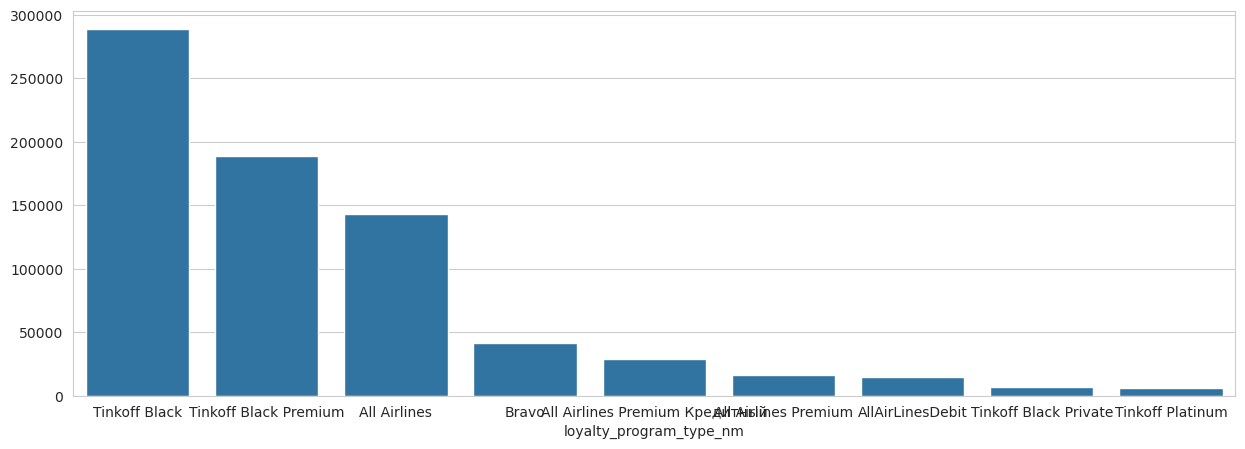

In [16]:
def my_analis(data_set, column, figsize=(10, 5)):
    nan_percent = data_set[column].isna().mean() * 100
    nan_count = data_set[column].isna().sum()
    count_unique = data_set[column].nunique()
    top_values = data_set[column].value_counts(dropna=False, ascending=False).head(count_unique if count_unique <= 10 else 10)
    types = data_set[column].apply(type).value_counts()
    print(f"1) Процент пустых записей: {nan_percent}")
    print(f"2) Количество пустых записей: {nan_count}")
    print(f"3) Количество уникальных записей: {count_unique}")
    print(f"4) Топ уникальных записей для {top_values}:")
    print(f"5) Количество типов записей: {types}")
    with sns.axes_style("whitegrid"):
        plt.figure(figsize=figsize)
        sns.barplot(
            y=top_values.values, 
            x=top_values.index)


my_analis(df, "loyalty_program_type_nm", (15, 5))

# Удаление мало заполненных и других ненужных столбцов. А также доработка данных (bounce_cd).


**Процент незаполненных:**
- children_cnt                    13.905218
- monthly_income_amt              19.482306
- promo_code_discount_amt         26.322287
- order_item_cnt                  26.389637
- avia_dep_city                   26.397053
- avia_arr_city                   26.397053
- bundle_nm                       29.653993
- marital_status_cd               37.688202
- lvn_city_nm                     43.061686
- loyalty_accrual_rub_amt         43.135376
- education_level_cd              43.165163
- book_end_dttm                   79.478382
- hotel_city                      80.590905
- hotel_country                   80.590905
- free_cancel_booking_dttm        90.956267

**Нижнее - УДАЛЯЕМ (много пустых):**
- last_email_send_dt              97.631643
- bad_email_address_flg           97.631643
- good_email_address_flg          97.631643
- call_contact_3m_flg             99.967581
- call_contact_1m_flg             99.967581
- call_contact_6m_flg             99.967581
- cancel_dttm                    100.000000

**Другие столбцы для удаления (эти данные точно не буду сейчас использовать):**
- birth_place - Место рождения
- last_session_dttm - Дата последней сессии
- account_rk - Идентификатор счета
- local_book_start_dttm - Дата заезда в местном часовом поясе (для отелей)
- time_zone_cd - Код часового пояса
- time_zone_delta_tm - Разница часового пояса с Гринвичем

In [17]:
# Мало данных:
cols_to_drop = [
    "last_email_send_dt", "bad_email_address_flg", "good_email_address_flg", "call_contact_3m_flg", "call_contact_1m_flg", 
    "call_contact_6m_flg", "cancel_dttm"]

df2 = df.drop(columns=cols_to_drop)

In [18]:
# Эти данные точно не буду сейчас использовать
cols_to_drop = [
    "birth_place", "last_session_dttm", "account_rk", "local_book_start_dttm", "time_zone_cd", 
    "time_zone_delta_tm"]

df2 = df2.drop(columns=cols_to_drop)

1) Процент пустых записей: 95.25383461452883
2) Количество пустых записей: 796263
3) Количество уникальных записей: 10
4) Топ уникальных записей для bounce_cd
NaN     796263
5,0      25261
15,0      7693
17,0      5403
13,0       400
14,0       366
9,0        257
10,0       192
11,0        62
2,0         25
Name: count, dtype: int64:
5) Количество типов записей: bounce_cd
<class 'float'>    796263
<class 'str'>       39675
Name: count, dtype: int64


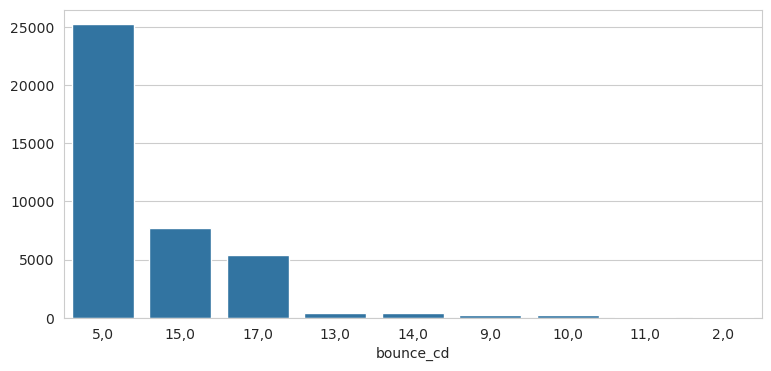

In [19]:
my_analis(df2, "bounce_cd", (9, 4))

bounce_cd - Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
Тогда заменяем NaN на 1 (доставлено), а остльные занчения на 0 (не доставлено)

# Просмотр общих параметров уже изменённого датасета df2

#### Info()

In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  Int64         
 1   client_rk                    835938 non-null  object        
 2   order_rk                     835938 non-null  object        
 3   loyalty_program_type_nm      754957 non-null  object        
 4   bundle_nm                    588049 non-null  object        
 5   order_type_cd                786885 non-null  object        
 6   order_status_cd              779514 non-null  object        
 7   party_first_order_dt         786885 non-null  datetime64[ns]
 8   party_first_order_type_dt    786767 non-null  datetime64[ns]
 9   free_cancel_booking_dttm     75600 non-null   datetime64[ns]
 10  created_dttm                 786885 non-null  datetime64[ns]
 11  book_start_dttm           

#### Процент незаполненных

In [21]:
df2["bounce_cd"] = df2["bounce_cd"].apply(lambda x: 1 if pd.isna(x) else 0)

In [22]:
nan_percent = df2.isna().mean() * 100
print(nan_percent)

order_online_payment_flg        5.868019
client_rk                       0.000000
order_rk                        0.000000
loyalty_program_type_nm         9.687441
bundle_nm                      29.653993
order_type_cd                   5.868019
order_status_cd                 6.749783
party_first_order_dt            5.868019
party_first_order_type_dt       5.882135
free_cancel_booking_dttm       90.956267
created_dttm                    5.868019
book_start_dttm                 5.868019
book_end_dttm                  79.478382
hotel_country                  80.590905
hotel_city                     80.590905
avia_dep_city                  26.397053
avia_arr_city                  26.397053
promo_code_discount_amt        26.322287
loyalty_accrual_rub_amt        43.135376
nominal_price_eur_amt           5.868019
nominal_price_rub_amt           5.868019
order_item_cnt                 26.389637
month_beginning_balance_rub     7.095024
monthly_income_amt             19.482306
suppress_email_f

#### Количество уникальных значений

In [23]:
count_unique = df2.nunique()
print(len(count_unique))
count_unique

43


order_online_payment_flg            1
client_rk                      148364
order_rk                       786886
loyalty_program_type_nm            36
bundle_nm                           9
order_type_cd                       2
order_status_cd                     7
party_first_order_dt             2500
party_first_order_type_dt        2497
free_cancel_booking_dttm        11325
created_dttm                   786883
book_start_dttm                 99276
book_end_dttm                     558
hotel_country                     133
hotel_city                       3248
avia_dep_city                     532
avia_arr_city                     541
promo_code_discount_amt            88
loyalty_accrual_rub_amt          8726
nominal_price_eur_amt            3154
nominal_price_rub_amt           72052
order_item_cnt                      9
month_beginning_balance_rub    103762
monthly_income_amt               2668
suppress_email_flg                  2
suppress_call_flg                   2
bounce_cd   

# Анализ возможных статусов заказов

1) Процент пустых записей: 6.74978287863454
2) Количество пустых записей: 56424
3) Количество уникальных записей: 7
4) Топ уникальных записей для order_status_cd
SUC    759950
NaN     56424
PRC     18467
ERR       650
NSH       304
CNC        84
REJ        58
Name: count, dtype: int64:
5) Количество типов записей: order_status_cd
<class 'str'>      779514
<class 'float'>     56424
Name: count, dtype: int64


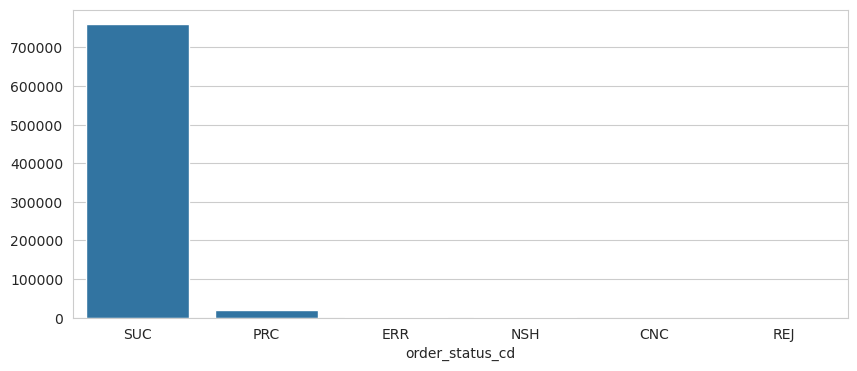

In [24]:
my_analis(df2, "order_status_cd", (10, 4))

Основные три статуса это: SUC, NaN и PRC. Или "успешно", "пусто" и "в процессе" соответственно. Остальные статусы не будем исследовать из-за их незначительности.

# Разделение датасета по типам заказа: отель (HOT), авиабилет (AIR) и без заказа (NaN)

In [55]:
df2['order_type_cd'].unique()

array(['AIR', 'HOT', nan], dtype=object)

In [120]:
df2_HOT = df2[(df2['order_type_cd'] == 'HOT')] 

df2_AIR = df2[(df2['order_type_cd'] == 'AIR')] 

df2_NaN = df2[(df2['order_type_cd'].isna())] 

### Просмотр уникальных статусов заказа для отелей (HOT)

In [121]:
df2_HOT['order_status_cd'].unique()

array(['SUC', nan, 'REJ', 'NSH', 'CNC'], dtype=object)

In [122]:
df2_HOT['order_status_cd'].value_counts()

order_status_cd
SUC    163794
NSH       304
REJ        58
CNC        21
Name: count, dtype: int64

**Статус заказа: Nan**

In [123]:
df2_HOT['order_status_cd'].isna().sum()

7371

In [124]:
df2_HOT[df2_HOT['order_status_cd'].isna()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 7371 entries, 3 to 835875
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_online_payment_flg     7371 non-null   Int64         
 1   client_rk                    7371 non-null   object        
 2   order_rk                     7371 non-null   object        
 3   loyalty_program_type_nm      5625 non-null   object        
 4   bundle_nm                    5996 non-null   object        
 5   order_type_cd                7371 non-null   object        
 6   order_status_cd              0 non-null      object        
 7   party_first_order_dt         7371 non-null   datetime64[ns]
 8   party_first_order_type_dt    7312 non-null   datetime64[ns]
 9   free_cancel_booking_dttm     3375 non-null   datetime64[ns]
 10  created_dttm                 7371 non-null   datetime64[ns]
 11  book_start_dttm              7371 non-null   d

**Судя по всему это какие-то неудачные заказы. В них также не указаны отель (страна + город), а также даже количсетво позиций в заказе => УДАЛЯЕМ**

In [125]:
df2_HOT = df2_HOT.dropna(subset=['order_status_cd'])

**Также удаляем строки с другими мало встречающимимся статусами в 'order_status_cd': NSH, REJ, CNC**

In [126]:
df2_HOT = df2_HOT[~df2_HOT['order_status_cd'].isin(['NSH', 'REJ', 'CNC'])]

**Проверка значений**

In [127]:
df2_HOT['order_status_cd'].unique()

array(['SUC'], dtype=object)

In [128]:
df2_HOT['order_status_cd'].value_counts()

order_status_cd
SUC    163794
Name: count, dtype: int64

### Просмотр уникальных статусов заказа для авиабилетов (AIR)

In [129]:
df2_AIR['order_status_cd'].unique()

array(['SUC', 'PRC', 'ERR', 'CNC', 'BRN'], dtype=object)

In [130]:
df2_AIR['order_status_cd'].value_counts()

order_status_cd
SUC    596156
PRC     18467
ERR       650
CNC        63
BRN         1
Name: count, dtype: int64

In [131]:
df2_AIR['order_status_cd'].isna().sum()

0

**Оставляем два самых часто встречающихся статуса: SUC и PRC, то есть "успешно" и "в процессе" соответственно. Остальные - УДАЛЯЕМ. Пустных значений (NaN) - нет**

In [133]:
df2_AIR = df2_AIR[~df2_AIR['order_status_cd'].isin(['ERR', 'CNC', 'BRN'])]

**Проверка значений**

In [134]:
df2_AIR['order_status_cd'].unique()

array(['SUC', 'PRC'], dtype=object)

In [135]:
df2_AIR['order_status_cd'].value_counts()

order_status_cd
SUC    596156
PRC     18467
Name: count, dtype: int64

### Наглядное сравнение бронирований отелей и заказов авиабилетов

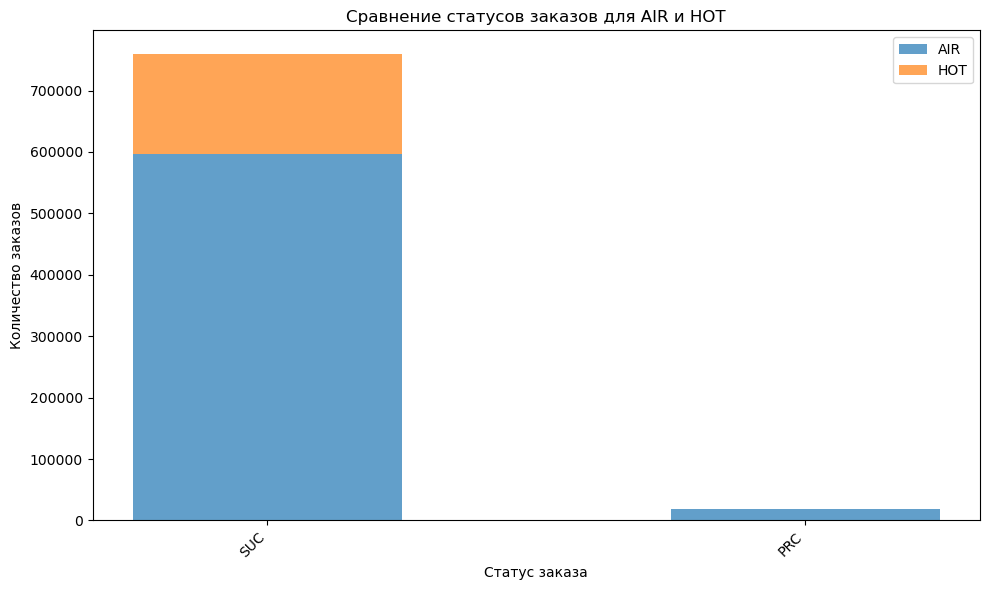

In [146]:
# Агрегируем данные по статусам для df2_AIR и df2_HOT
air_status_counts = df2_AIR['order_status_cd'].value_counts()
hot_status_counts = df2_HOT['order_status_cd'].value_counts()

# Собираем все уникальные статусы для оси X
status_labels = list(set(air_status_counts.index).union(hot_status_counts.index))  # все статусы
air_counts = [air_status_counts.get(label, 0) for label in status_labels]
hot_counts = [hot_status_counts.get(label, 0) for label in status_labels]

# Строим столбчатый график с наложением
bar_width = 0.50  # ширина столбцов
x = range(len(status_labels))  # индексы для столбцов

plt.figure(figsize=(10, 6))

# Строим два столбца с разделением по статусам
plt.bar(x, air_counts, width=bar_width, label='AIR', alpha=0.7)
plt.bar(x, hot_counts, width=bar_width, bottom=air_counts, label='HOT', alpha=0.7)  # Наложение HOT на AIR

# Добавляем подписи и легенду
plt.xlabel('Статус заказа')
plt.ylabel('Количество заказов')
plt.title('Сравнение статусов заказов для AIR и HOT')
plt.xticks(x, status_labels, rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

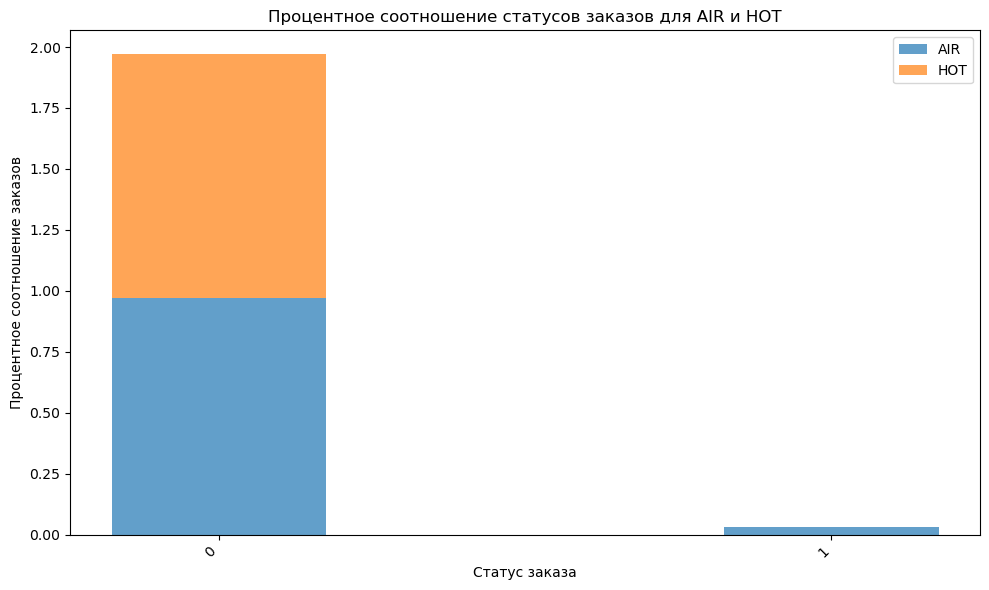

In [145]:
import matplotlib.pyplot as plt

# Агрегируем данные по статусам для df2_AIR и df2_HOT
air_status_counts = df2_AIR['order_status_cd'].value_counts(normalize=True)  # нормализуем для процента
hot_status_counts = df2_HOT['order_status_cd'].value_counts(normalize=True)  # нормализуем для процента

# Собираем все уникальные статусы для оси X

air_counts = [air_status_counts.get(label, 0) for label in status_labels]
hot_counts = [hot_status_counts.get(label, 0) for label in status_labels]

# Строим столбчатый график с наложением
bar_width = 0.35  # ширина столбцов
x = range(len(status_labels))  # индексы для столбцов

plt.figure(figsize=(10, 6))

# Строим два столбца с разделением по статусам
plt.bar(x, air_counts, width=bar_width, label='AIR', alpha=0.7)
plt.bar(x, hot_counts, width=bar_width, bottom=air_counts, label='HOT', alpha=0.7)  # Наложение HOT на AIR

# Добавляем подписи и легенду
plt.xlabel('Статус заказа')
plt.ylabel('Процентное соотношение заказов')
plt.title('Процентное соотношение статусов заказов для AIR и HOT')
plt.xticks(x, rotation=45, ha='right')

# Легенда
plt.legend()

plt.tight_layout()
plt.show()

### Просмотр заказов с невыбранным типом Отель (HOT) или Авиабилет (AIR),  то есть 'order_type_cd' == NaN

In [64]:
df2_NaN['order_status_cd'].unique()

array([nan], dtype=object)

In [84]:
df2_NaN.shape

(49053, 43)

In [137]:
df2_NaN['client_rk'].nunique()

49053

In [86]:
df2['order_rk'].value_counts(dropna=False, ascending=False).head(10)

order_rk
9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6c9bc9d493a23be9de0    49053
fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e638d5746c1c7adbcc5a0        1
f8ff89531ccbbe2c6a19c68458f73de48dfabdfe3ce10907a7f047658cc0c0df        1
f3b815b9a14cef1fc4ce25ee3543ee5ac18c158fc6edeb98c734b51d755f7226        1
455ba382f9cbc5c691e4d82e0b88694916b112d4d6f46069424637e2364134e3        1
cb60bd2a051f7530c7d6d91184550bf90a0204aaa3e517e7ccf072765bba7fa9        1
dd96b552ae8d655a1e17789f528a1d9673002214f6e3548cfd2dbb1eaa582dfa        1
230e8295629101504cdcf43c33689b18ff08954ed2d5a6b74400f77231316d45        1
707a9fc7f3d1b7561c4104d5a15b6617969afb3cdc60d4a875791f6ff6acbcf4        1
38886291241859cf3005da351b7d7201be789f9e59c81f2d1154ce086161dd72        1
Name: count, dtype: int64

In [138]:
df2_NaN['order_rk'].value_counts()

order_rk
9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6c9bc9d493a23be9de0    49053
Name: count, dtype: int64

In [139]:
df2_NaN['client_rk'].nunique()

49053

**Таким образом, каждой записи из df2_NaN (не HOT и не AIR) соответствует ровно один id клиента без повторов. Также у каждой такой записи один и тот же id заказа. Поэтому будем считать, что все записи в df2_NaN соответствуют клиентам не совершившим ни одного заказа.**

#### Оставили только три самых часто встречающихся статусов заказов, считая NaN

In [ ]:
(df2['order_status_cd'].isin(['SUC', 'PRC']) | df2['order_status_cd'].isna())].copy()

In [ ]:
(df2['order_status_cd'].isin(['SUC', 'PRC']) | df2['order_status_cd'].isna())].copy()

# Соотношение заказов авиабилетов и бронирования отеля

Таким образом все статусы 

# Временная зависимость бронирования отелей

In [31]:
df_hotels = df2[(df2['order_type_cd'] == 'HOT')].copy()

start_date = pd.to_datetime('2024-01-01')
end_date   = pd.to_datetime('2024-12-30')
df_hotels = df_hotels[(df_hotels['created_dttm'] >= start_date) & (df_hotels['created_dttm'] <= end_date)]

df_hotels['date'] = df_hotels['created_dttm'].dt.date

counts_of_bookings = df_hotels.groupby(['date', 'order_status_cd']).size().reset_index()
counts_of_bookings

,date,order_status_cd,0
0,2024-01-01,CNC,2
1,2024-01-01,SUC,222
2,2024-01-02,NSH,1
3,2024-01-02,SUC,273
4,2024-01-03,SUC,279
...,...,...,...
550,2024-11-03,SUC,433
551,2024-11-04,SUC,387
552,2024-11-05,SUC,510
553,2024-11-06,SUC,488


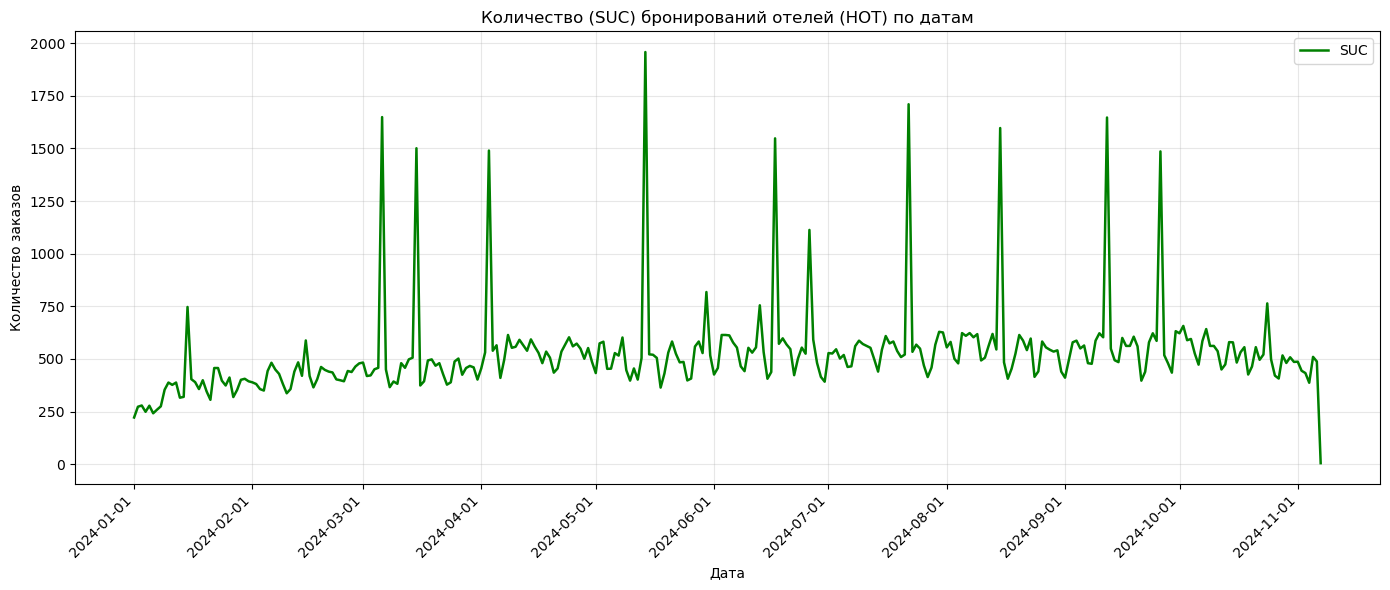

In [32]:
import matplotlib.dates as mdates


def plot_group(data, group, figsize=(14,6), color='blue'):
    subset = data[data['order_status_cd'] == group]
    
    plt.figure(figsize=figsize)
    plt.plot(subset['date'], subset[0], label=group, linewidth=1.8, color=color)
    
    plt.title(f'Количество ({group}) бронирований отелей (HOT) по датам')
    plt.xlabel('Дата')
    plt.ylabel('Количество заказов')
    
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_group(counts_of_bookings, 'SUC', color='green')

Явно наблюдаются резкие пики успешных бронирований впоть до нескольких тысяч. Предположительно они могут быть связаны либо с акциями, ибо с праздниками и другими сезонными мерояприятиями.
Также можно отметить, что заказы со статусом 

# Временная зависимость бронирования авиабилетов

In [33]:
df_hotels = df2[(df2['order_type_cd'] == 'AIR')].copy()

start_date = pd.to_datetime('2024-01-01')
end_date   = pd.to_datetime('2024-12-30')
df_hotels = df_hotels[(df_hotels['created_dttm'] >= start_date) & (df_hotels['created_dttm'] <= end_date)]

df_hotels['date'] = df_hotels['created_dttm'].dt.date

counts_of_bookings = df_hotels.groupby(['date', 'order_status_cd']).size().reset_index()

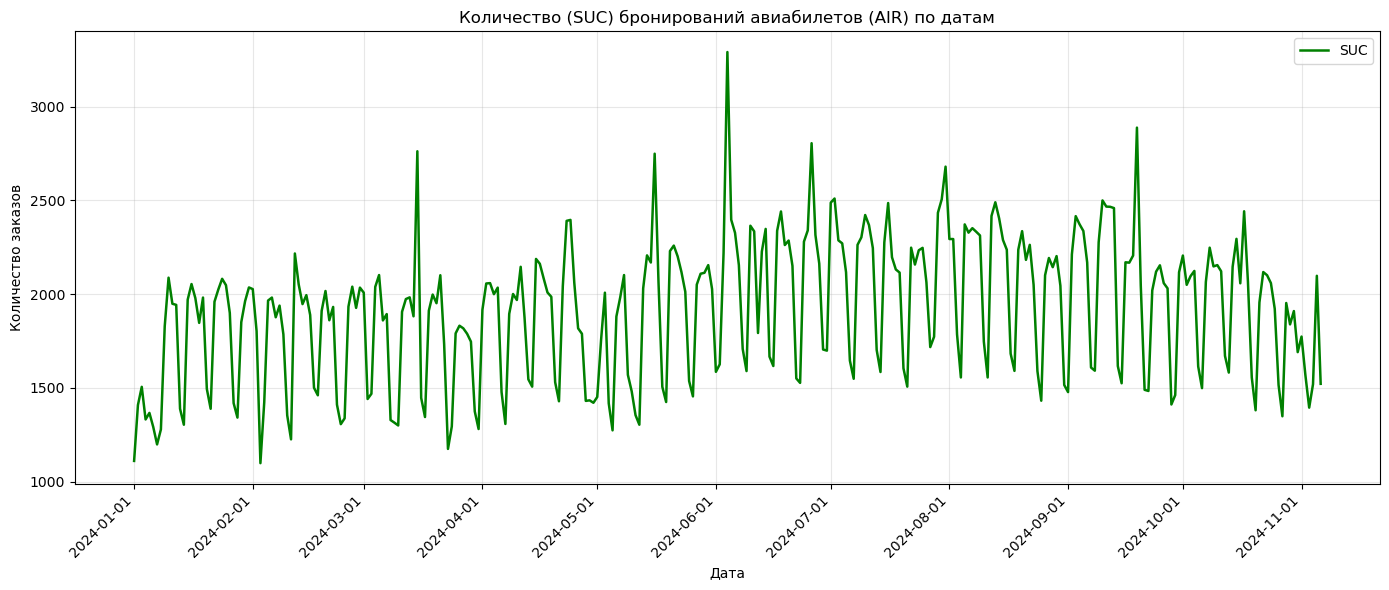

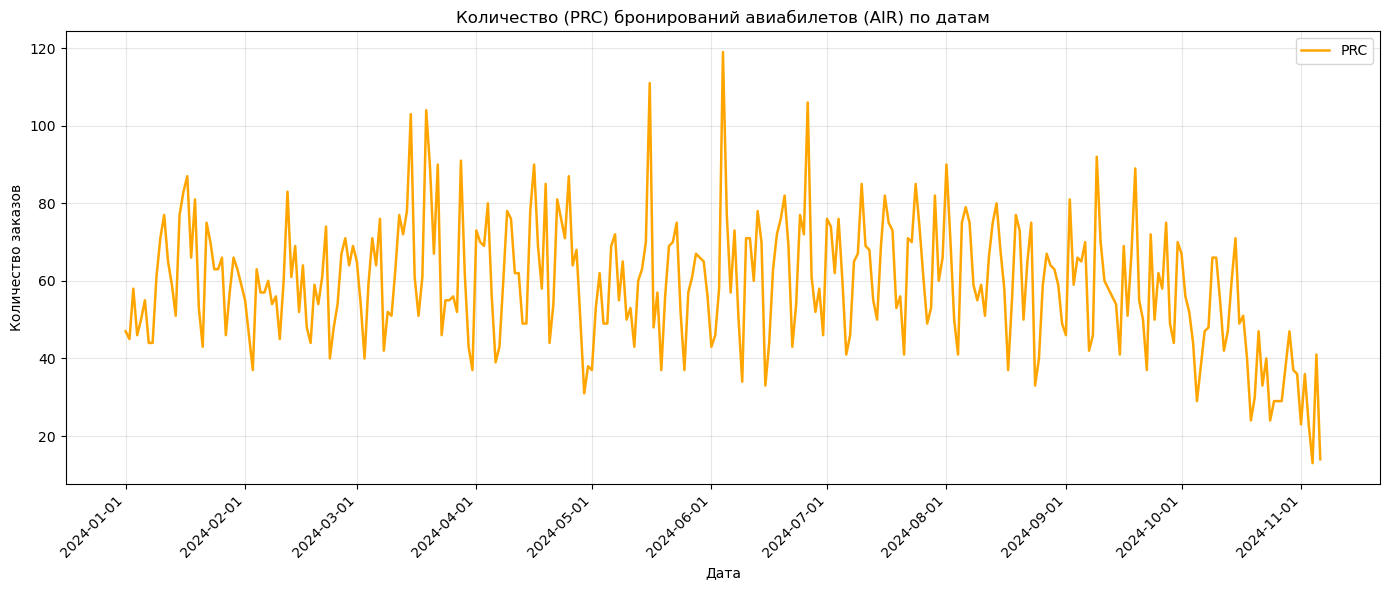

In [34]:
import matplotlib.dates as mdates

def plot_group(data, group, figsize=(14,6), color='blue'):
    subset = data[data['order_status_cd'] == group]
    
    plt.figure(figsize=figsize)
    plt.plot(subset['date'], subset[0], label=group, linewidth=1.8, color=color)
    
    plt.title(f'Количество ({group}) бронирований авиабилетов (AIR) по датам')
    plt.xlabel('Дата')
    plt.ylabel('Количество заказов')
    
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Строим три отдельных графика
plot_group(counts_of_bookings, 'SUC', color='green')
plot_group(counts_of_bookings, 'PRC', color='orange')

# Доля клиентов в дата сете, успешно совершивших покупку

In [35]:
clients_with_SUC = df2.loc[df2['order_status_cd'] == 'SUC']
clients_without_SUC = df2.loc[df2['order_status_cd'] != 'SUC',]

amount_all_clients = df2['client_rk'].nunique()
amount_clients_with_SUC = clients_with_SUC['client_rk'].nunique()


a = amount_clients_with_SUC / amount_all_clients

print(f"Уникальных клиентов всего: {amount_all_clients}")
print(f"Клиентов с покупкой (SUC): {amount_clients_with_SUC}")
print(f"Доля клиентов с покупкой: {a * 100}%")

Уникальных клиентов всего: 148364
Клиентов с покупкой (SUC): 99232
Доля клиентов с покупкой: 66.88414979375051%


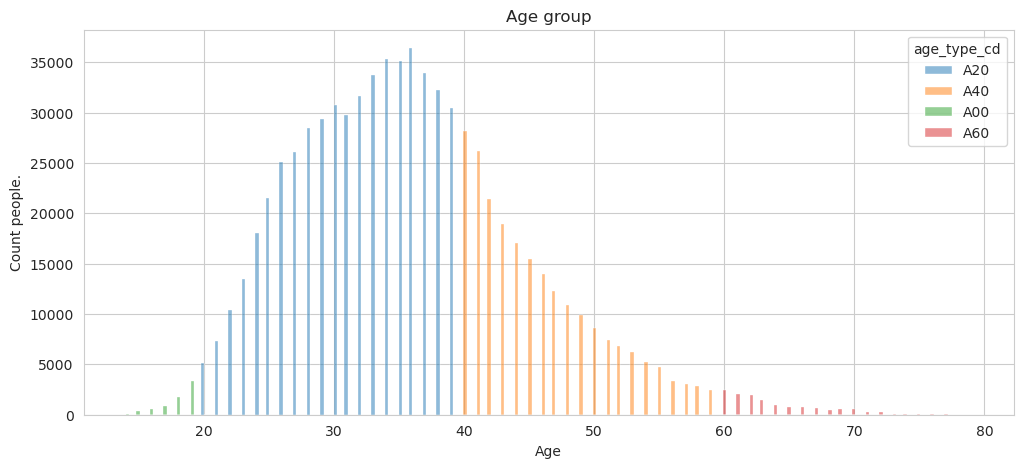

In [36]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(12,5))
    ax = sns.histplot(data=df2[df2['order_status_cd'].isin(["SUC"])], x='age', hue='age_type_cd', kde=False)
    ax.set(xlabel='Age',
           ylabel='Count people.',
           title='Age group'
    )

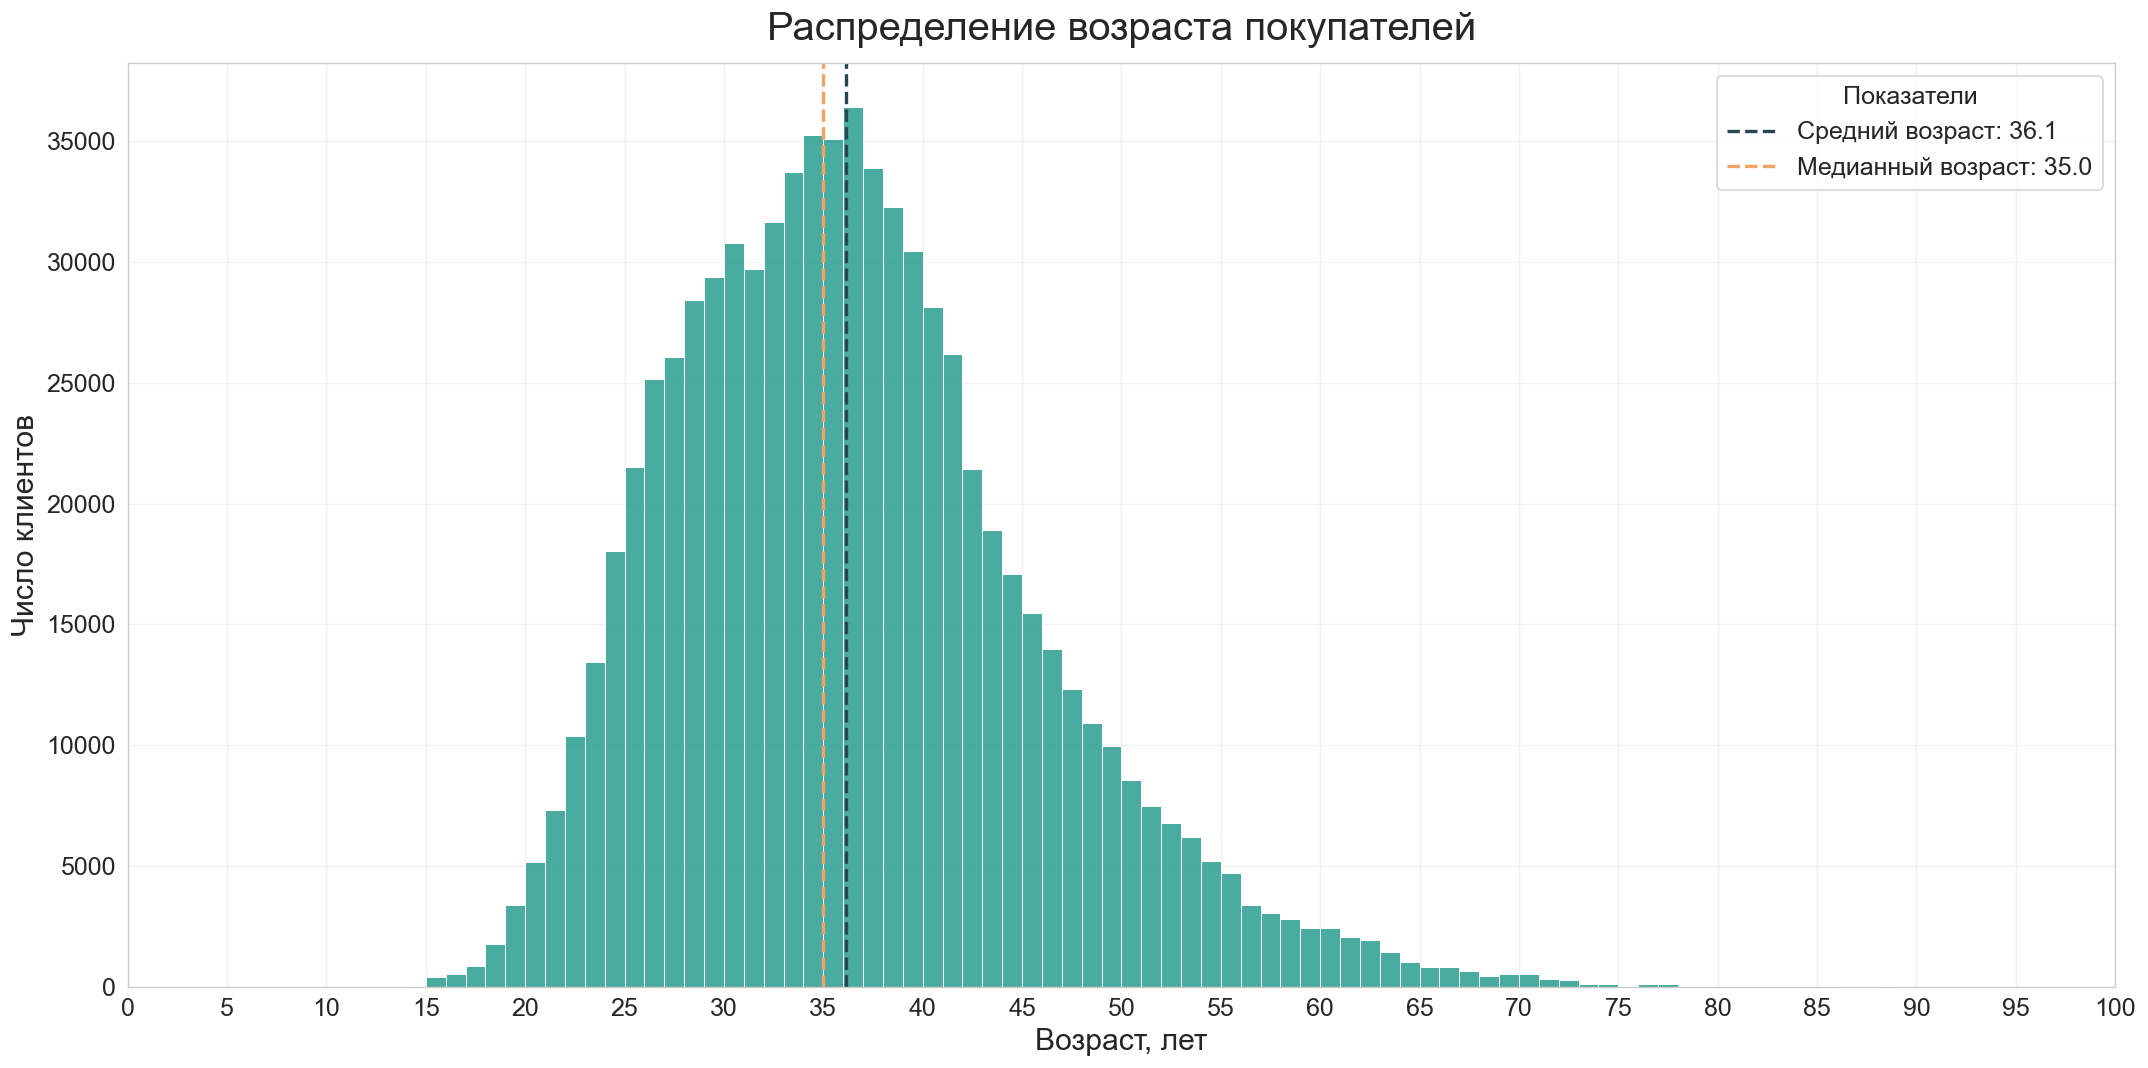

In [37]:
buyers = df2[df2['order_status_cd'].isin(["SUC"])].copy()

mean_age = buyers["age"].mean()
median_age = buyers["age"].median()

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(18, 9), dpi=120)

    # Гистограмма по 1 году
    sns.histplot(
        data=buyers,
        x="age",
        bins=range(0, 101, 1),     # бины по 1 году
        color="#2A9D8F",           # насыщённый бирюзовый
        edgecolor="white",
        linewidth=0.6,
        alpha=0.85,
        stat="count",              # можно заменить на "percent", если нужна доля
        ax=ax
    )

    # Вертикальные линии среднего и медианы
    ax.axvline(mean_age,   color="#264653", linestyle="--", linewidth=2,
               label=f"Средний возраст: {mean_age:.1f}")
    ax.axvline(median_age, color="#F4A261", linestyle="--", linewidth=2,
               label=f"Медианный возраст: {median_age:.1f}")

    # Подписи и оформление
    ax.set_title("Распределение возраста покупателей", fontsize=24, pad=14)
    ax.set_xlabel("Возраст, лет", fontsize=18)
    ax.set_ylabel("Число клиентов", fontsize=18)

    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 5))
    ax.tick_params(axis="both", labelsize=15)
    ax.grid(True, which="major", alpha=0.25)

    # Легенда
    ax.legend(title="Показатели", title_fontsize=15, fontsize=15, frameon=True, loc="upper right")

    plt.tight_layout()
    plt.show()

In [38]:
tmp = df2.assign(suc = (df2["order_status_cd"] == "SUC").astype("Int64"))

by_client = tmp.groupby(["age_type_cd", "client_rk"], dropna=True)["suc"].max().reset_index()

share_by_age = (by_client.groupby("age_type_cd")["suc"].mean() * 100).sort_index()

age_labels = {
    "A00": "0–19 лет",
    "A20": "20–39 лет",
    "A40": "40–59 лет",
    "A60": "60+ лет"
}

share_by_age = share_by_age.rename(index=age_labels)

print(share_by_age.round(2))

age_type_cd
0–19 лет      23.6
20–39 лет    69.31
40–59 лет    66.93
60+ лет      52.38
Name: suc, dtype: Float64


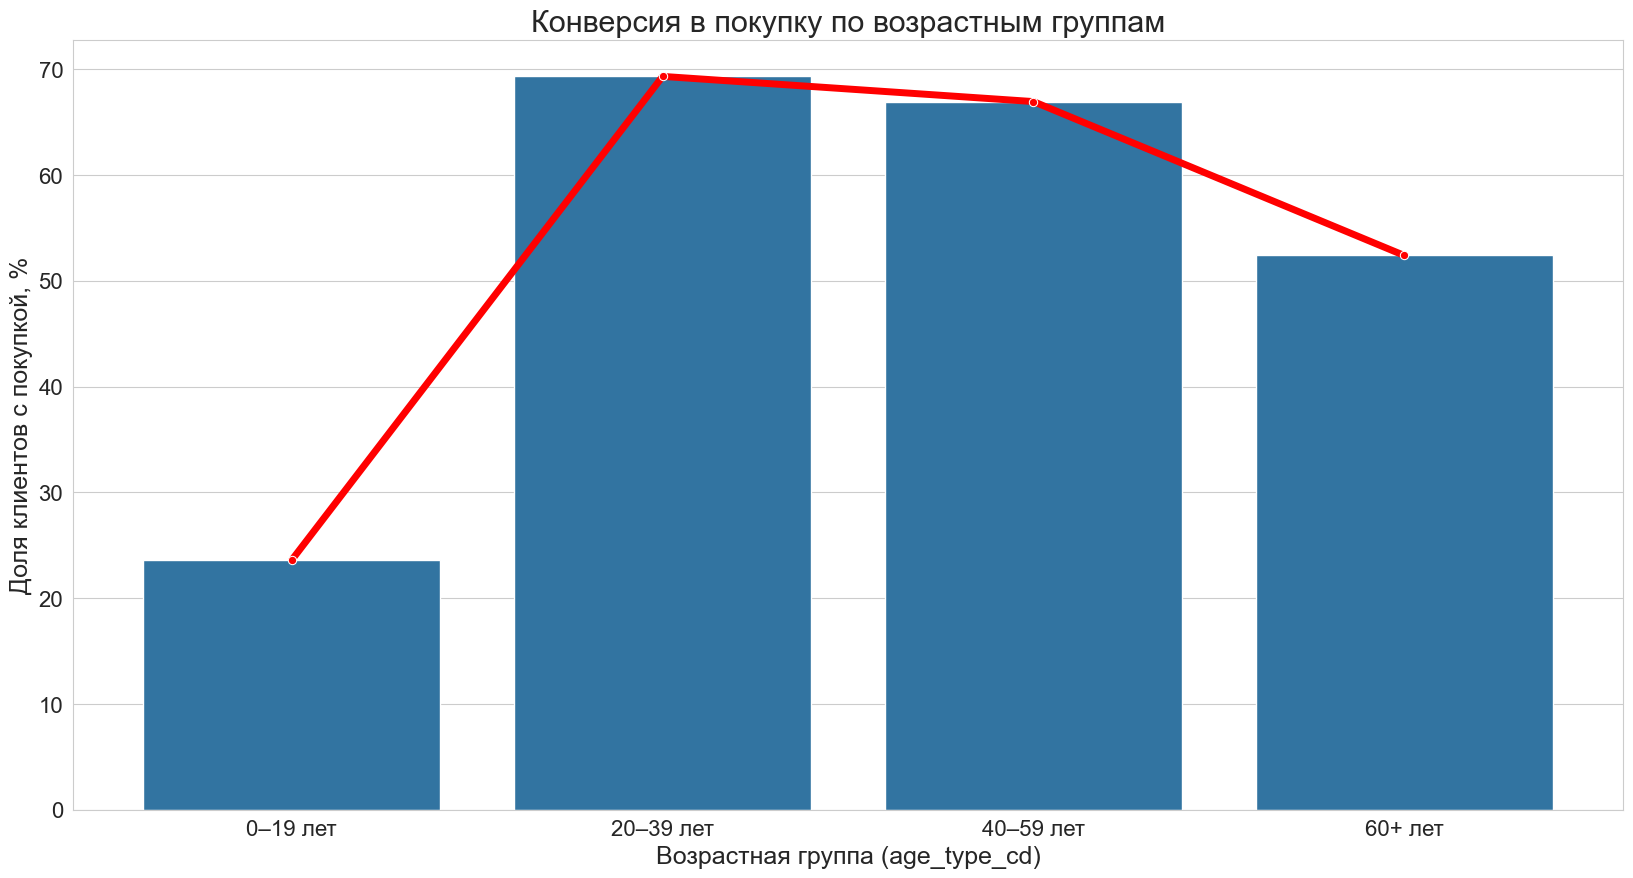

In [39]:
with sns.axes_style("whitegrid"):
    plt.figure(figsize=(20,10))
    sns.barplot(
        y=share_by_age.values,
        x=share_by_age.index
    )
    sns.lineplot(
    x=share_by_age.index,
    y=share_by_age.values,
    color="red",
    marker="o",
    linewidth=5
    )
    plt.xlabel("Возрастная группа (age_type_cd)", fontsize=18)
    plt.ylabel("Доля клиентов с покупкой, %", fontsize=18)
    plt.title("Конверсия в покупку по возрастным группам", fontsize=22)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

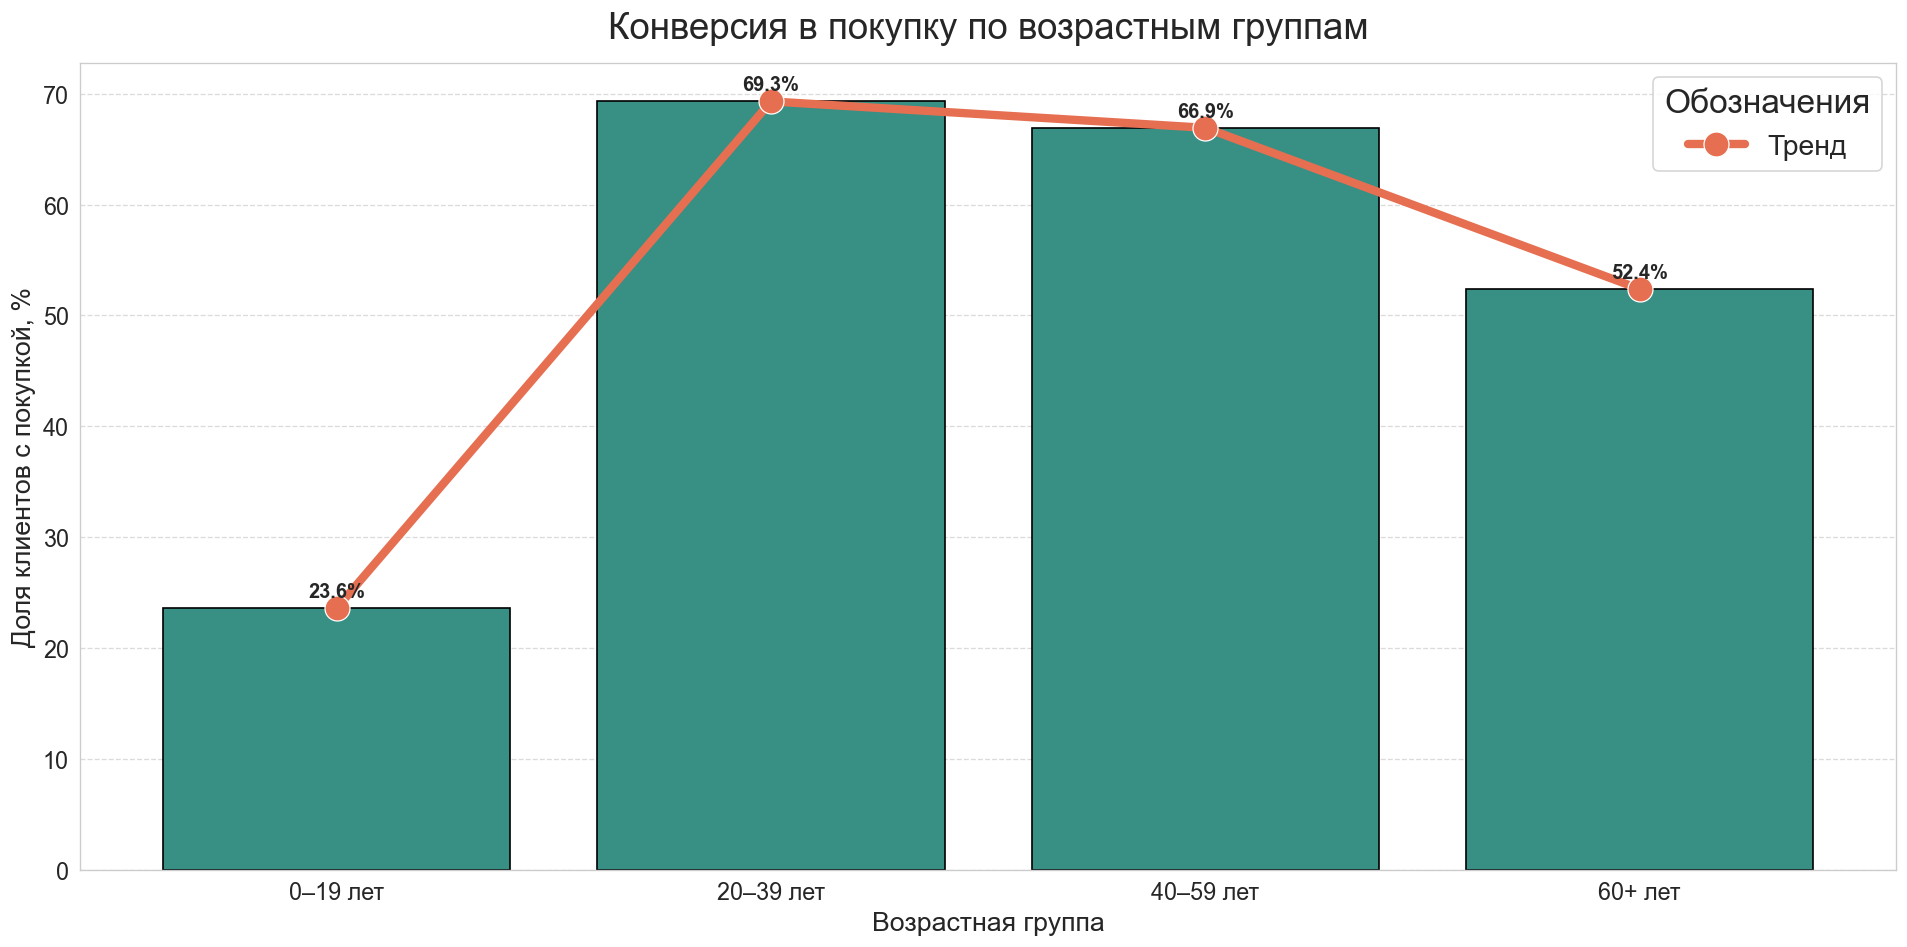

In [40]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(16, 8), dpi=120)

    # 1. Столбчатая диаграмма
    bars = sns.barplot(
        x=share_by_age.index,
        y=share_by_age.values,
        color="#2A9D8F",   # насыщенный бирюзовый
        edgecolor="black",
        ax=ax
    )

    # 2. Линия поверх баров
    sns.lineplot(
        x=share_by_age.index,
        y=share_by_age.values,
        color="#E76F51",   # коралловый для акцента
        marker="o",
        linewidth=5,
        markersize=15,
        ax=ax,
        label="Тренд"
    )

    # 3. Подписи процентов над столбцами
    for idx, value in enumerate(share_by_age.values):
        ax.text(idx, value + 1, f"{value:.1f}%", ha="center", fontsize=12, fontweight="bold")

    # 4. Подписи и оформление
    ax.set_title("Конверсия в покупку по возрастным группам", fontsize=22, pad=15)
    ax.set_xlabel("Возрастная группа", fontsize=16)
    ax.set_ylabel("Доля клиентов с покупкой, %", fontsize=16)

    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    # сетка только по горизонтали
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    ax.legend(fontsize=17, title="Обозначения", title_fontsize=20)

    plt.tight_layout()
    plt.show()

In [41]:
tmp = df2.assign(suc = (df2["order_status_cd"] == "SUC").astype("Int64"))

by_client = tmp.groupby(["age", "client_rk"], dropna=True)["suc"].max().reset_index()
by_client

,age,client_rk,suc
0,14.0,02faf9402d922ef6d6cb32aecbbd0f3086a72aac60f3c9...,0
1,14.0,03eca97bf9ccdbe094f8db8fb77b5159e41587349f0a54...,1
2,14.0,07679fc55c1aa61452ec4b188e79d7161a926bd4141194...,0
3,14.0,07b89899d74c1801d35268603435a8d14e2805bfa7afdf...,0
4,14.0,08bdd8e6415dc159a8df61b39cf3f1e932ba1341987e5d...,0
...,...,...,...
148358,89.0,d0c04f56ab8df46437589c74a103a3847f62658898d974...,0
148359,89.0,f4faf06e3bec36a781901fe8a2e28f16abb094d3e34907...,0
148360,90.0,60bc2fc8070d5f28baf4db3f0231130027f2e79e1136b5...,0
148361,92.0,134e1246a628fdb9d5d8f4671e19767c45b1703450a3b3...,0


In [42]:
share_by_age = (by_client.groupby("age")["suc"].mean() * 100).sort_index()
print(share_by_age.round(2))

age
14.0    10.26
15.0    13.01
16.0    15.66
17.0    17.73
18.0    23.22
        ...  
88.0    100.0
89.0      0.0
90.0      0.0
92.0      0.0
98.0    100.0
Name: suc, Length: 79, dtype: Float64


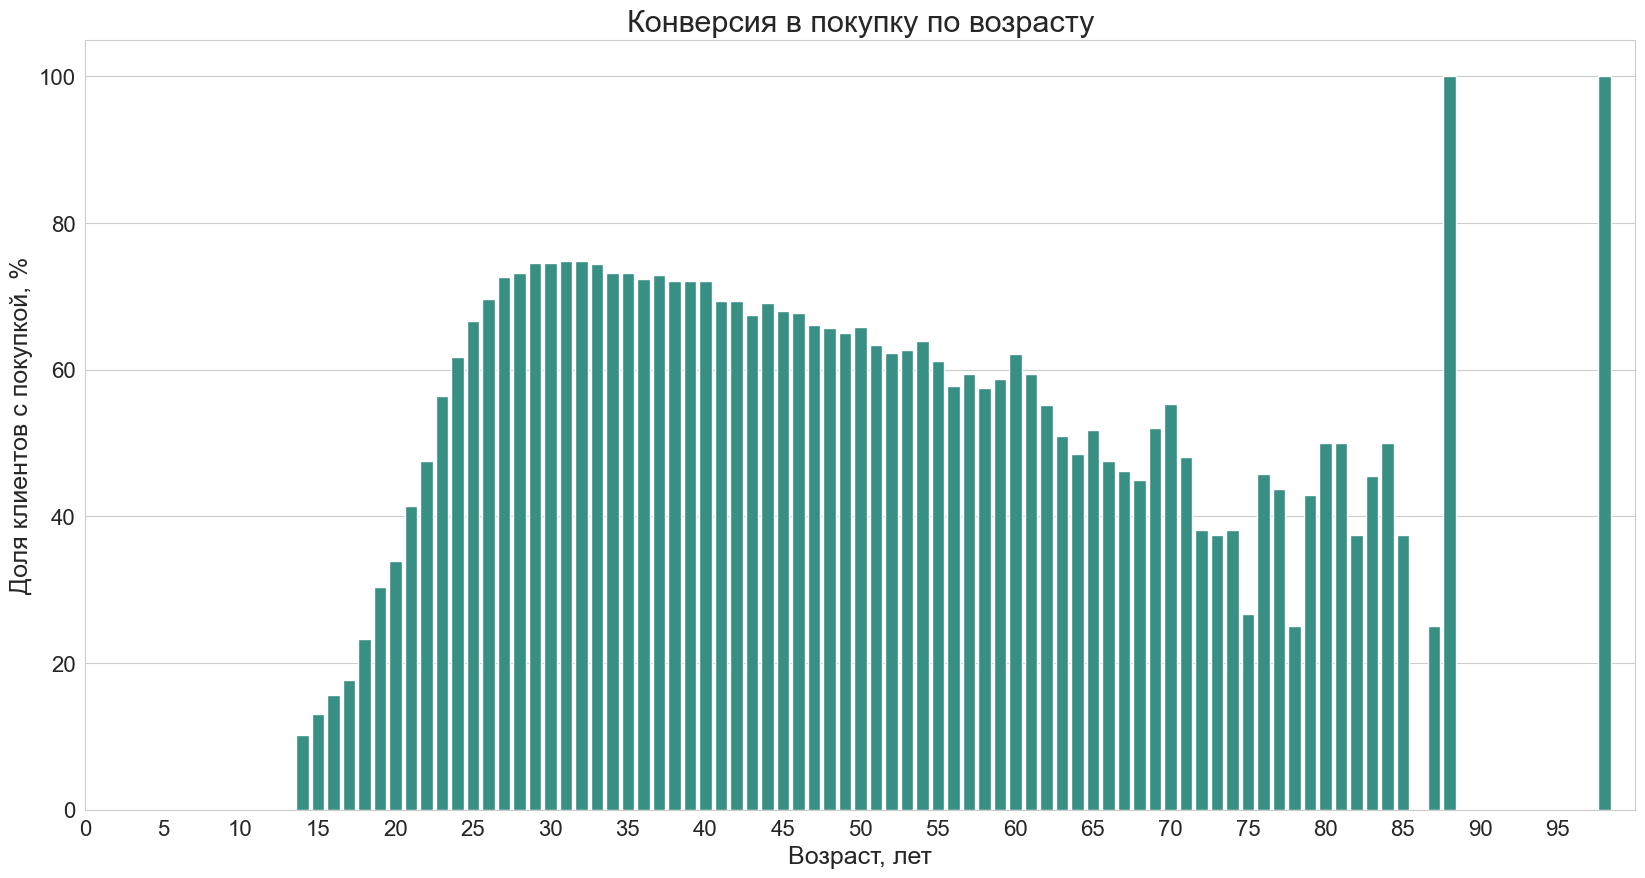

In [43]:
# достаём минимальный и максимальный возраст
min_age = int(share_by_age.index.min())
max_age = int(share_by_age.index.max())

# создаём полный диапазон возрастов от 0 до max_age
full_index = range(0, max_age + 1)

# переиндексируем с заполнением пропусков NaN (там где данных нет)
share_by_age_full = share_by_age.reindex(full_index, fill_value=0)

with sns.axes_style("whitegrid"):
    plt.figure(figsize=(20,10))
    sns.barplot(
        y=share_by_age_full.values,
        x=share_by_age_full.index,
        color="#2A9D8F"
    )

    plt.xlabel("Возраст, лет", fontsize=18)
    plt.ylabel("Доля клиентов с покупкой, %", fontsize=18)
    plt.title("Конверсия в покупку по возрасту", fontsize=22)

    # начинаем ось с 0
    plt.xlim(0, max_age + 1)

    # метки через 5 лет начиная с 0
    step = 5
    plt.xticks(
        ticks=range(0, max_age + step, step),
        fontsize=16
    )

    plt.yticks(fontsize=16)
    plt.show()

## Уведомления, sms и email:
- suppress_email_flg - Отказ от коммуникаций по почте
- suppress_call_flg - Отказ от коммуникаций по телефону
- bounce_cd - Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
- last_sms_success_flg - Было ли последнее СМС успешным
- mobile_phone_operator_nm - Оператор мобильной связи
- last_sms_dt - Дата отправки последнего СМС
- email_valid_flg - Флаг валидности имейла


In [44]:
# Процент пустых полей
for i in [
    "suppress_email_flg",
    "suppress_call_flg",
    "bounce_cd",
    "last_sms_success_flg",
    "mobile_phone_operator_nm",
    "last_sms_dt",
    "email_valid_flg"]:
    print(f"{i}\t {nan_percent[i]:.2}%")

suppress_email_flg	 0.0%
suppress_call_flg	 0.0%
bounce_cd	 0.0%
last_sms_success_flg	 0.24%
mobile_phone_operator_nm	 0.15%
last_sms_dt	 0.24%
email_valid_flg	 0.0%


In [45]:
cols = ["bundle_nm", "promo_code_discount_amt", "loyalty_accrual_rub_amt", "loyalty_program_type_nm"]

for c in cols:
    print(c)
    print(df2.groupby("order_status_cd")[c].apply(lambda s: s.notna().mean()*100))
    print()

bundle_nm
order_status_cd
BRN    100.000000
CNC     73.809524
ERR     83.076923
NSH     84.539474
PRC     74.987816
REJ     82.758621
SUC     74.649253
Name: bundle_nm, dtype: float64

promo_code_discount_amt
order_status_cd
BRN    100.000000
CNC     75.000000
ERR    100.000000
NSH      0.000000
PRC    100.000000
REJ      3.448276
SUC     78.520561
Name: promo_code_discount_amt, dtype: float64

loyalty_accrual_rub_amt
order_status_cd
BRN     0.000000
CNC    50.000000
ERR    54.769231
NSH    55.263158
PRC    37.542644
REJ    13.793103
SUC    61.562734
Name: loyalty_accrual_rub_amt, dtype: float64

loyalty_program_type_nm
order_status_cd
BRN    100.000000
CNC     94.047619
ERR     95.846154
NSH     99.342105
PRC     95.814155
REJ    100.000000
SUC     96.134614
Name: loyalty_program_type_nm, dtype: float64



In [46]:
cols = ["bundle_nm", "promo_code_discount_amt", "loyalty_accrual_rub_amt", "loyalty_program_type_nm"]

for c in cols:
    print(c)
    print(df2.groupby(c)["order_status_cd"].apply(lambda s: s.eq("SUC").mean()*100))
    print()

bundle_nm
bundle_nm
Premium             96.207520
Private             94.536107
Pro                 96.799952
Team Premium        94.660194
Team Private       100.000000
Team Pro            96.666667
Team Select         97.047970
Tinkoff Premium    100.000000
Tinkoff Pro        100.000000
Name: order_status_cd, dtype: float64

promo_code_discount_amt
promo_code_discount_amt
0.0         96.848312
50.0         0.000000
67.0         0.000000
100.0       99.867900
168.0        0.000000
              ...    
18145.0    100.000000
33500.0    100.000000
39002.0    100.000000
45763.0    100.000000
67000.0    100.000000
Name: order_status_cd, Length: 88, dtype: float64

loyalty_accrual_rub_amt
loyalty_accrual_rub_amt
-8645.0        0.0
-2202.0        0.0
-2137.0        0.0
-1786.0        0.0
-1710.0        0.0
             ...  
 100085.0    100.0
 130576.0      0.0
 131985.0    100.0
 180809.0    100.0
 606732.0    100.0
Name: order_status_cd, Length: 8726, dtype: float64

loyalty_program_type

In [47]:
cols = ["bundle_nm", "promo_code_discount_amt", "loyalty_accrual_rub_amt", "loyalty_program_type_nm"]

for c in cols:
    print(c)
    print(df2.groupby(df2[c].isna())["order_status_cd"].apply(lambda s: s.eq("SUC").mean()*100))
    print()

bundle_nm
bundle_nm
False    96.471042
True     77.717446
Name: order_status_cd, dtype: float64

promo_code_discount_amt
promo_code_discount_amt
False    96.885371
True     74.184005
Name: order_status_cd, dtype: float64

loyalty_accrual_rub_amt
loyalty_accrual_rub_amt
False    98.420753
True     81.008361
Name: order_status_cd, dtype: float64

loyalty_program_type_nm
loyalty_program_type_nm
False    96.770412
True     36.273941
Name: order_status_cd, dtype: float64



In [48]:
f = df2.groupby("client_rk")["order_status_cd"].apply(lambda s: s.eq("SUC").max()).values.mean()
f

0.668841497937505

In [49]:
# общее число уникальных клиентов
total_clients = df2["client_rk"].nunique()

# число клиентов, у которых есть хотя бы один SUC
clients_with_purchase = df2.loc[df2["order_status_cd"].notna(), "client_rk"].nunique()

# процент
percent_clients_with_purchase = clients_with_purchase / total_clients * 100

print(f"Всего уникальных клиентов: {total_clients}")
print(f"Клиентов с покупкой: {clients_with_purchase}")
print(f"Процент клиентов с покупкой: {percent_clients_with_purchase:.2f}%")

Всего уникальных клиентов: 148364
Клиентов с покупкой: 99273
Процент клиентов с покупкой: 66.91%


In [50]:
df2.groupby(df2["order_status_cd"].notna())["order_online_payment_flg"].apply(lambda s: s.notna().mean()*100)

order_status_cd
False     13.06359
True     100.00000
Name: order_online_payment_flg, dtype: float64

In [51]:
df2.groupby(df2["order_online_payment_flg"].notna())["order_status_cd"].apply(lambda s: s.notna().mean()*100)

order_online_payment_flg
False     0.000000
True     99.063268
Name: order_status_cd, dtype: float64